# Filter rare subposes and review retained photos

This notebook removes subtypes with fewer than `MIN_TRAIN_SAMPLES` training images. The keep/remove decision is learned from training counts and then applied unchanged to both train and test data. It exports filtered CSVs, count summaries, a chart, and an in-notebook gallery of every retained photo grouped by subtype.

In [1]:
from html import escape
import os
from pathlib import Path
from urllib.parse import quote

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

MIN_TRAIN_SAMPLES = 10


def find_project_root(start: Path = Path.cwd()) -> Path:
    for directory in (start.resolve(), *start.resolve().parents):
        input_dir = directory / 'csv_data' / 'keypoint_dbscan_subposes'
        if (input_dir / 'keypoints_train_dbscan_subposes.csv').is_file():
            return directory
    raise FileNotFoundError('Could not find csv_data/keypoint_dbscan_subposes.')


PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / 'code'
INPUT_DIR = PROJECT_ROOT / 'csv_data' / 'keypoint_dbscan_subposes'
OUTPUT_DIR = PROJECT_ROOT / 'csv_data' / 'keypoint_filtered_subposes'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILES = {
    split: INPUT_DIR / f'keypoints_{split}_dbscan_subposes.csv'
    for split in ('train', 'test')
}
OUTPUT_FILES = {
    split: OUTPUT_DIR / f'keypoints_{split}_filtered_subposes.csv'
    for split in ('train', 'test')
}
SUMMARY_FILE = OUTPUT_DIR / 'subpose_filter_summary.csv'
POSE_SUMMARY_FILE = OUTPUT_DIR / 'pose_filter_summary.csv'
CHART_FILE = OUTPUT_DIR / 'subpose_filter_chart.png'

PROJECT_ROOT

WindowsPath('C:/Users/vgohu/Desktop/yoga_project')

In [2]:
datasets = {split: pd.read_csv(path) for split, path in INPUT_FILES.items()}
required_columns = {'label', 'subpose_id', 'pose_side', 'subpose_label'}
for split, dataframe in datasets.items():
    missing = required_columns.difference(dataframe.columns)
    if missing:
        raise ValueError(f'{split} is missing columns: {sorted(missing)}')

PATH_COLUMN = datasets['train'].columns[0]
train_subpose_counts = datasets['train']['subpose_label'].value_counts().sort_index()
retained_subposes = set(train_subpose_counts[train_subpose_counts >= MIN_TRAIN_SAMPLES].index)
removed_subposes = set(train_subpose_counts.index).difference(retained_subposes)

filtered_datasets = {
    split: dataframe[dataframe['subpose_label'].isin(retained_subposes)].copy()
    for split, dataframe in datasets.items()
}
removed_datasets = {
    split: dataframe[~dataframe['subpose_label'].isin(retained_subposes)].copy()
    for split, dataframe in datasets.items()
}

for split, dataframe in filtered_datasets.items():
    dataframe.to_csv(OUTPUT_FILES[split], index=False)

pd.DataFrame({
    'setting': ['minimum training images', 'retained subtype labels', 'removed subtype labels'],
    'value': [MIN_TRAIN_SAMPLES, len(retained_subposes), len(removed_subposes)],
})

,setting,value
0,minimum training images,10
1,retained subtype labels,9
2,removed subtype labels,6


In [3]:
all_subposes = sorted(set().union(*(set(df['subpose_label']) for df in datasets.values())))
summary = pd.DataFrame({'subpose_label': all_subposes})
summary['status'] = np.where(summary['subpose_label'].isin(retained_subposes), 'retained', 'removed')

for split in ('train', 'test'):
    total_counts = datasets[split]['subpose_label'].value_counts()
    summary[f'{split}_total'] = summary['subpose_label'].map(total_counts).fillna(0).astype(int)
    summary[f'{split}_retained'] = np.where(
        summary['status'].eq('retained'), summary[f'{split}_total'], 0
    )
    summary[f'{split}_removed'] = summary[f'{split}_total'] - summary[f'{split}_retained']

summary['total'] = summary['train_total'] + summary['test_total']
summary['retained'] = summary['train_retained'] + summary['test_retained']
summary['removed'] = summary['train_removed'] + summary['test_removed']
summary.to_csv(SUMMARY_FILE, index=False)

pose_rows = []
for pose in sorted(set().union(*(set(df['label']) for df in datasets.values()))):
    row = {'pose': pose}
    for split in ('train', 'test'):
        row[f'{split}_total'] = int(datasets[split]['label'].eq(pose).sum())
        row[f'{split}_retained'] = int(filtered_datasets[split]['label'].eq(pose).sum())
        row[f'{split}_removed'] = int(removed_datasets[split]['label'].eq(pose).sum())
    row['total'] = row['train_total'] + row['test_total']
    row['retained'] = row['train_retained'] + row['test_retained']
    row['removed'] = row['train_removed'] + row['test_removed']
    pose_rows.append(row)
pose_summary = pd.DataFrame(pose_rows)
pose_summary.to_csv(POSE_SUMMARY_FILE, index=False)

display(HTML('<h3>Counts by subtype</h3>'))
display(summary)
display(HTML('<h3>Counts by original pose</h3>'))
display(pose_summary)

,subpose_label,status,train_total,train_retained,train_removed,test_total,test_retained,test_removed,total,retained,removed
0,downdog_subpose_1,retained,199,199,0,94,94,0,293,293,0
1,goddess_subpose_1,removed,4,0,4,0,0,0,4,0,4
2,goddess_subpose_2,retained,162,162,0,78,78,0,240,240,0
3,goddess_subpose_3,removed,6,0,6,2,0,2,8,0,8
4,plank_subpose_1,retained,13,13,0,1,1,0,14,14,0
5,plank_subpose_2,retained,124,124,0,44,44,0,168,168,0
6,plank_subpose_3,removed,8,0,8,2,0,2,10,0,10
7,plank_subpose_4,retained,118,118,0,68,68,0,186,186,0
8,tree_left_subpose_1,removed,4,0,4,0,0,0,4,0,4
9,tree_left_subpose_2,retained,50,50,0,29,29,0,79,79,0


,pose,train_total,train_retained,train_removed,test_total,test_retained,test_removed,total,retained,removed
0,downdog,199,199,0,94,94,0,293,293,0
1,goddess,172,162,10,80,78,2,252,240,12
2,plank,263,255,8,115,113,2,378,368,10
3,tree,159,150,9,69,69,0,228,219,9
4,warrior2,249,249,0,107,107,0,356,356,0


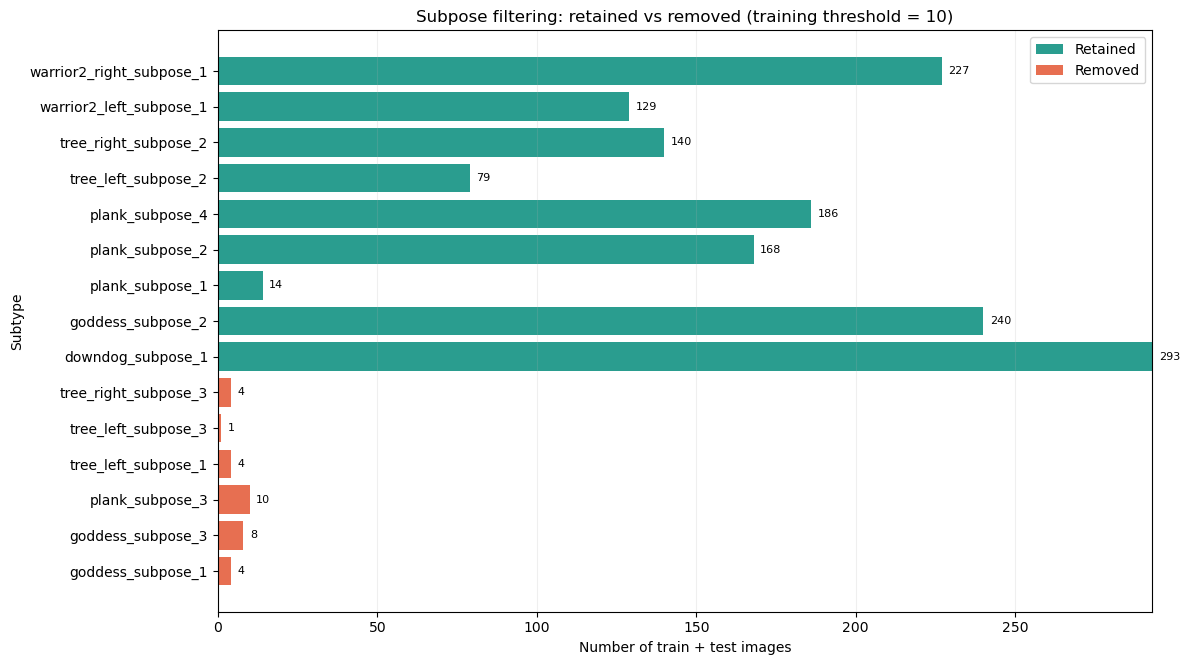

In [4]:
chart_data = summary.sort_values(['status', 'subpose_label']).set_index('subpose_label')
fig_height = max(6, 0.45 * len(chart_data))
fig, ax = plt.subplots(figsize=(12, fig_height))
ax.barh(chart_data.index, chart_data['retained'], color='#2a9d8f', label='Retained')
ax.barh(
    chart_data.index,
    chart_data['removed'],
    left=chart_data['retained'],
    color='#e76f51',
    label='Removed',
)
for row_number, (_, row) in enumerate(chart_data.iterrows()):
    ax.text(row['total'] + 2, row_number, str(row['total']), va='center', fontsize=8)
ax.set_title(f'Subpose filtering: retained vs removed (training threshold = {MIN_TRAIN_SAMPLES})')
ax.set_xlabel('Number of train + test images')
ax.set_ylabel('Subtype')
ax.legend()
ax.grid(axis='x', alpha=0.2)
fig.tight_layout()
fig.savefig(CHART_FILE, dpi=160, bbox_inches='tight')
plt.show()

In [5]:
def resolve_image_path(csv_path: str) -> Path | None:
    relative = Path(str(csv_path).replace('\\', '/'))
    without_data_prefix = Path(*relative.parts[1:]) if relative.parts and relative.parts[0].lower() == 'data' else relative
    candidates = [
        PROJECT_ROOT / relative,
        PROJECT_ROOT / 'data' / 'test' / without_data_prefix,
        PROJECT_ROOT / 'data' / 'raw' / 'DATASET' / without_data_prefix,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    return None


def notebook_image_source(image_path: Path) -> str:
    relative = os.path.relpath(image_path, NOTEBOOK_DIR).replace('\\', '/')
    return quote(relative, safe='/:._-')


def display_retained_photo_gallery(dataframes: dict[str, pd.DataFrame]) -> pd.DataFrame:
    gallery_data = pd.concat(
        [dataframe.assign(dataset_split=split) for split, dataframe in dataframes.items()],
        ignore_index=True,
    )
    path_checks = []

    for subtype, group in gallery_data.groupby('subpose_label', sort=True):
        cards = []
        for _, row in group.iterrows():
            raw_path = str(row[PATH_COLUMN])
            resolved = resolve_image_path(raw_path)
            found = resolved is not None
            path_checks.append({'subpose_label': subtype, 'csv_path': raw_path, 'found': found})
            caption = escape(f"{row['dataset_split']}: {Path(raw_path).name}")
            if found:
                source = notebook_image_source(resolved)
                image_html = f'<img loading="lazy" src="{source}" alt="{caption}">'
            else:
                image_html = '<div class="missing">Image not found</div>'
            cards.append(f'<figure>{image_html}<figcaption>{caption}</figcaption></figure>')

        gallery_html = f'''
        <details open>
          <summary><strong>{escape(subtype)}</strong> — {len(group)} retained photos</summary>
          <div class="subpose-grid">{''.join(cards)}</div>
        </details>
        '''
        display(HTML(gallery_html))

    return pd.DataFrame(path_checks)


display(HTML('''
<style>
.subpose-grid { display:grid; grid-template-columns:repeat(auto-fill,minmax(125px,1fr)); gap:8px; margin:10px 0 24px; }
.subpose-grid figure { margin:0; padding:5px; border:1px solid #ddd; border-radius:5px; background:#fff; }
.subpose-grid img, .subpose-grid .missing { width:100%; height:115px; object-fit:contain; background:#f4f4f4; }
.subpose-grid figcaption { font-size:10px; overflow-wrap:anywhere; margin-top:4px; }
.subpose-grid .missing { display:flex; align-items:center; justify-content:center; color:#b00020; }
details summary { cursor:pointer; font-size:15px; margin-top:12px; }
</style>
'''))

In [6]:
display(HTML('<h2>Every retained photo, grouped by subtype</h2>'))
image_path_report = display_retained_photo_gallery(filtered_datasets)
path_summary = image_path_report['found'].value_counts().rename_axis('image_found').to_frame('photos')
display(HTML('<h3>Image-path validation</h3>'))
display(path_summary)
if not image_path_report['found'].all():
    display(image_path_report[~image_path_report['found']])

,photos
image_found,
True,1476


In [7]:
for split in ('train', 'test'):
    assert len(filtered_datasets[split]) + len(removed_datasets[split]) == len(datasets[split])
    assert set(filtered_datasets[split]['subpose_label']).issubset(retained_subposes)
    assert set(removed_datasets[split]['subpose_label']).isdisjoint(retained_subposes)
    assert OUTPUT_FILES[split].is_file()
assert (train_subpose_counts[list(retained_subposes)] >= MIN_TRAIN_SAMPLES).all()
assert (train_subpose_counts[list(removed_subposes)] < MIN_TRAIN_SAMPLES).all()
assert SUMMARY_FILE.is_file() and POSE_SUMMARY_FILE.is_file() and CHART_FILE.is_file()
assert image_path_report['found'].all(), 'At least one retained image path could not be resolved.'

print(f'Retained train rows: {len(filtered_datasets["train"]):,}')
print(f'Removed train rows:  {len(removed_datasets["train"]):,}')
print(f'Retained test rows:  {len(filtered_datasets["test"]):,}')
print(f'Removed test rows:   {len(removed_datasets["test"]):,}')
print(f'Gallery photos:      {len(image_path_report):,}')

Retained train rows: 1,015
Removed train rows:  27
Retained test rows:  461
Removed test rows:   4
Gallery photos:      1,476


## Outputs

All files are saved under `csv_data/keypoint_filtered_subposes/`:

- `keypoints_train_filtered_subposes.csv`
- `keypoints_test_filtered_subposes.csv`
- `subpose_filter_summary.csv`
- `pose_filter_summary.csv`
- `subpose_filter_chart.png`